# Model Interpretation

Knowing that a model is accurate is only half the story.
The other half is understanding **why** it makes the decisions it does.

This notebook goes deeper into interpreting the models we trained.
We look at what each model learned about credit risk, compare how they
explain their decisions, and draw conclusions about which features
are the most reliable predictors of default.

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

## Loading Models and Data

We load all three models and the test set to run interpretation analysis.

In [2]:
X_train = np.load('../data/X_train_processed.npy')
X_test  = np.load('../data/X_test_processed.npy')
y_train = np.load('../data/y_train.npy')
y_test  = np.load('../data/y_test.npy')
feature_names = np.load('../data/feature_names.npy', allow_pickle=True)

lr_model = joblib.load('../models/logistic_regression.pkl')
rf_model = joblib.load('../models/random_forest.pkl')
gb_model = joblib.load('../models/gradient_boosting.pkl')

print('Everything loaded successfully.')
print(f'Features: {len(feature_names)}')

Everything loaded successfully.
Features: 44


## Logistic Regression — Coefficient Analysis

In Logistic Regression, every feature has a learned coefficient.
The sign tells us the direction (positive = increases risk of bad credit,
negative = decreases risk) and the size tells us the strength.

This is the most directly interpretable model of the three —
you can explain any individual prediction by simply looking at which
features pushed the probability up or down.

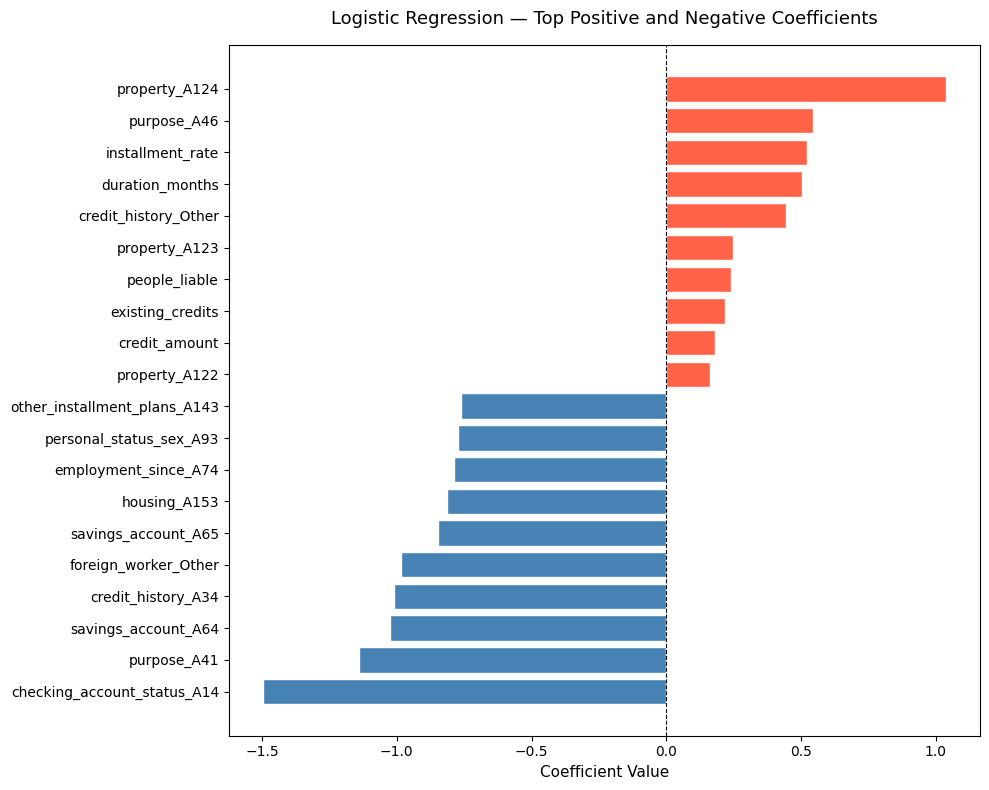

Features most associated with BAD credit (positive):
property_A124           1.0383
purpose_A46             0.5456
installment_rate        0.5225
duration_months         0.5045
credit_history_Other    0.4454
property_A123           0.2489
people_liable           0.2410
existing_credits        0.2183
credit_amount           0.1829
property_A122           0.1639
dtype: float64

Features most associated with GOOD credit (negative):
checking_account_status_A14    -1.4974
purpose_A41                    -1.1411
savings_account_A64            -1.0261
credit_history_A34             -1.0107
foreign_worker_Other           -0.9846
savings_account_A65            -0.8462
housing_A153                   -0.8136
employment_since_A74           -0.7861
personal_status_sex_A93        -0.7712
other_installment_plans_A143   -0.7622
dtype: float64


In [3]:
coefs = pd.Series(lr_model.coef_[0], index=feature_names)

top_pos = coefs.sort_values(ascending=False).head(10)
top_neg = coefs.sort_values(ascending=True).head(10)
top_all = pd.concat([top_pos, top_neg]).sort_values()

colors = ['tomato' if c > 0 else 'steelblue' for c in top_all.values]

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_all)), top_all.values, color=colors, edgecolor='white')
plt.yticks(range(len(top_all)), top_all.index, fontsize=10)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Logistic Regression — Top Positive and Negative Coefficients',
          fontsize=13, pad=15)
plt.xlabel('Coefficient Value', fontsize=11)
plt.tight_layout()
plt.show()

print('Features most associated with BAD credit (positive):')
print(top_pos.round(4))
print('\nFeatures most associated with GOOD credit (negative):')
print(top_neg.round(4))

## Permutation Importance — Model-Agnostic Method

Feature importance from Random Forest and Gradient Boosting is computed
using impurity reduction, which can be biased toward features with many
unique values.

**Permutation importance** is a more reliable alternative that works
for any model. The idea is simple:

1. Measure the model's ROC-AUC on the test set normally
2. Randomly shuffle the values of one feature — this breaks any relationship
   between that feature and the target
3. Measure ROC-AUC again — if it drops a lot, that feature was important.
   If it barely changes, the model did not rely on it much
4. Repeat for every feature

This gives us a fair, model-agnostic measure of feature importance
that is not influenced by the algorithm's internal structure.

Computing permutation importance for Random Forest...


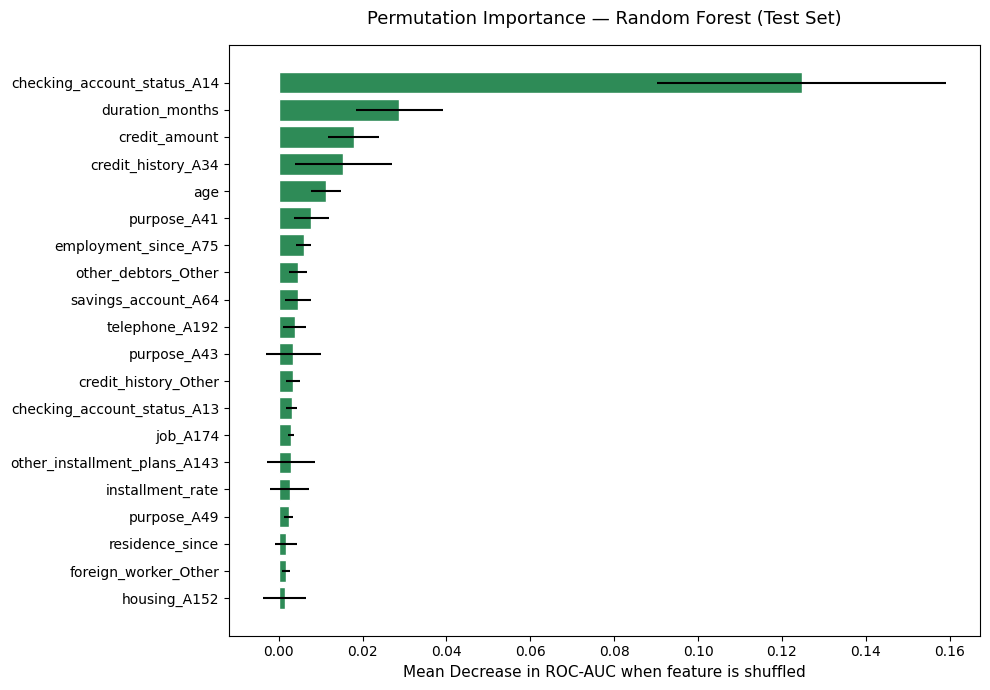

Top 10 features by permutation importance:
                    feature  importance      std
checking_account_status_A14    0.124714 0.034387
            duration_months    0.028726 0.010382
              credit_amount    0.017845 0.006001
         credit_history_A34    0.015417 0.011510
                        age    0.011274 0.003548
                purpose_A41    0.007798 0.004109
       employment_since_A75    0.005952 0.001747
        other_debtors_Other    0.004631 0.002096
        savings_account_A64    0.004607 0.003147
             telephone_A192    0.003774 0.002658


In [4]:
print('Computing permutation importance for Random Forest...')
perm_imp = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': perm_imp.importances_mean,
    'std':        perm_imp.importances_std
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(
    range(len(perm_df)),
    perm_df['importance'].values[::-1],
    xerr=perm_df['std'].values[::-1],
    color='seagreen', edgecolor='white'
)
plt.yticks(range(len(perm_df)), perm_df['feature'].values[::-1], fontsize=10)
plt.title('Permutation Importance — Random Forest (Test Set)',
          fontsize=13, pad=15)
plt.xlabel('Mean Decrease in ROC-AUC when feature is shuffled', fontsize=11)
plt.tight_layout()
plt.show()

print('Top 10 features by permutation importance:')
print(perm_df.head(10)[['feature', 'importance', 'std']].to_string(index=False))

## Comparing Feature Importance Across All Three Models

We now put all three models' feature rankings side by side.
Features that appear consistently important across all three models
are our most reliable findings — they are important regardless
of which algorithm we use.

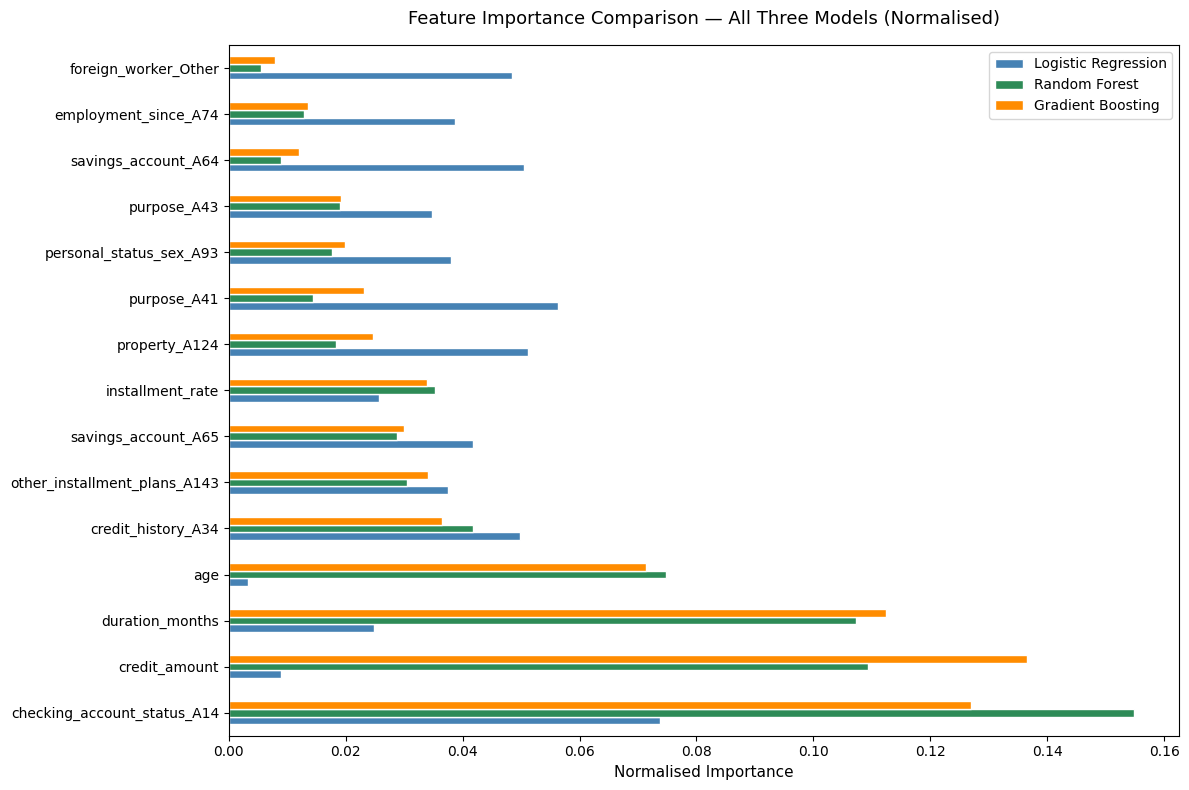

Top 10 features averaged across all models:
                              Logistic Regression  Random Forest  Gradient Boosting    mean
checking_account_status_A14                0.0738         0.1548             0.1270  0.1186
credit_amount                              0.0090         0.1094             0.1366  0.0850
duration_months                            0.0249         0.1072             0.1125  0.0815
age                                        0.0034         0.0748             0.0714  0.0498
credit_history_A34                         0.0498         0.0417             0.0365  0.0427
other_installment_plans_A143               0.0376         0.0306             0.0340  0.0341
savings_account_A65                        0.0417         0.0288             0.0300  0.0335
installment_rate                           0.0257         0.0353             0.0339  0.0316
property_A124                              0.0512         0.0183             0.0246  0.0313
purpose_A41                         

In [5]:
lr_imp = pd.Series(np.abs(lr_model.coef_[0]), index=feature_names)
rf_imp = pd.Series(rf_model.feature_importances_, index=feature_names)
gb_imp = pd.Series(gb_model.feature_importances_, index=feature_names)

# Normalise each to sum to 1 for fair comparison
lr_imp = lr_imp / lr_imp.sum()
rf_imp = rf_imp / rf_imp.sum()
gb_imp = gb_imp / gb_imp.sum()

# Take top 15 from any model
top_features = pd.concat([lr_imp, rf_imp, gb_imp], axis=1)
top_features.columns = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
top_features['mean'] = top_features.mean(axis=1)
top_features = top_features.sort_values('mean', ascending=False).head(15)

top_features.drop(columns='mean').plot(
    kind='barh',
    figsize=(12, 8),
    color=['steelblue', 'seagreen', 'darkorange'],
    edgecolor='white'
)
plt.title('Feature Importance Comparison — All Three Models (Normalised)',
          fontsize=13, pad=15)
plt.xlabel('Normalised Importance', fontsize=11)
plt.tight_layout()
plt.show()

print('Top 10 features averaged across all models:')
print(top_features.head(10).round(4).to_string())

## Prediction on a Single Applicant

To make the model tangible, we pick one applicant from the test set
and show what each model predicts for them — both the hard label
and the probability score.

This is what a real scoring system would do: take an applicant's data,
run it through the model, and output a risk probability.

In [6]:
# Pick first applicant from test set
applicant = X_test[0:1]
true_label = int(y_test[0])

print(f'True label: {"Bad Credit" if true_label == 1 else "Good Credit"}')
print()

for name, model in [('Logistic Regression', lr_model),
                     ('Random Forest',       rf_model),
                     ('Gradient Boosting',   gb_model)]:
    pred  = model.predict(applicant)[0]
    proba = model.predict_proba(applicant)[0][1]
    label = 'Bad Credit' if pred == 1 else 'Good Credit'
    print(f'{name}:')
    print(f'  Prediction:  {label}')
    print(f'  Probability of bad credit: {proba:.4f} ({proba*100:.1f}%)')
    print()

True label: Good Credit

Logistic Regression:
  Prediction:  Good Credit
  Probability of bad credit: 0.4775 (47.8%)

Random Forest:
  Prediction:  Good Credit
  Probability of bad credit: 0.4888 (48.9%)

Gradient Boosting:
  Prediction:  Good Credit
  Probability of bad credit: 0.3081 (30.8%)



## Summary

In this notebook we went beyond accuracy numbers and looked at what
the models actually learned.

The key findings are:

- Logistic Regression is the most directly interpretable — every coefficient
  has a clear meaning and direction
- Permutation importance gives a reliable, model-agnostic measure of
  which features actually matter when tested on unseen data
- Comparing feature importance across all three models reveals which features
  are genuinely predictive versus which ones are algorithm-specific artifacts
- All three models agree that **checking account status, credit amount,
  and loan duration** are the strongest predictors of credit default risk

